# Reconstruction using OpenCV

Your name: James Bishop

Your ID number: 9117504

No we're going to read two images in, a left image and a right image. And we are going to estimate the essential matrix between the two images.

In the last e-tivity, you estimated the homography that let us transform the images, at least approximately, so that we could line them up in a panorama. But it was a 2D estimation that works for planar scenes. The essential matrix, in a way, allows us to extend this concept beyond the need for a 2D scene, we can accept a 3D scene.

## Read the images, calibration, and do the feature extraction

Let's start by reading the two images.

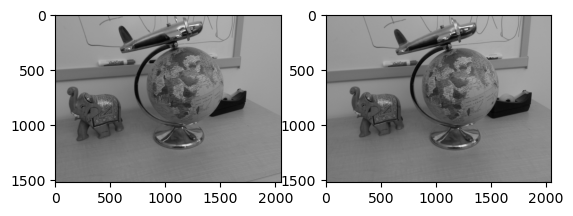

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

imgL_color = cv2.imread('globe1.jpg')
imgR_color = cv2.imread('globe2.jpg')

imgL_color = cv2.cvtColor(imgL_color, cv2.COLOR_BGR2RGB)
imgR_color = cv2.cvtColor(imgR_color, cv2.COLOR_BGR2RGB)

imgL = cv2.imread('globe1.jpg',cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread('globe2.jpg',cv2.IMREAD_GRAYSCALE)

f, axarr = plt.subplots(1,2)
axarr[0].imshow(imgL,cmap='gray')
axarr[1].imshow(imgR,cmap='gray');

We need the calibration to generate the essential matrix. We looked before at how to calibrate a camera, so we won't go through that again. Here, we just use the calibration.

In [49]:
# The calibration is the same for both images, as they were captured using the same camera.

# First two are radial distortion, second two are tangential, which we ignore (set to zero)
dist = np.array([0.138220594989358, -0.291158084324502, 0, 0])

# The projection matrix. 
K_init = np.array([[1901.61685419446, 0               , 1051.33708372959],
                   [0               , 1894.94457228005, 778.616424720309],
                   [0               , 0               , 1               ]])

h, w = imgL.shape[:2]


It's not obvious form the images above, but there is a slight radial distortion. We want to work with undistorted images (it makes our life a little easier). So, here, we undistort before the feature extraction.

In [66]:
# We're going to use OpenCV to do this.
# When you undistort, we change the camera matrix slightly. OpenCV provides a hady function that updates this.
K_new, roi = cv2.getOptimalNewCameraMatrix(K_init, dist, (w,h), 1, (w,h))

# Now we will undistort the image pair
imgL = cv2.undistort(imgL, K_init, dist, None, K_new)
imgR = cv2.undistort(imgR, K_init, dist, None, K_new)

# we will just store the new camera matrix
K = K_new
print(K)

[[1.90750838e+03 0.00000000e+00 1.05455479e+03]
 [0.00000000e+00 1.89845416e+03 7.80029253e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


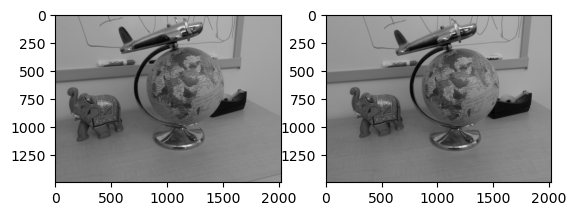

In [51]:
# crop the image. 
# Usefully, getOptimalNewCameraMatrix returns an roi that defines the area of the image without the black bits.
# Crop using np.array slicing
%matplotlib inline

x, y, w, h = roi
imgL = imgL[y:y+h, x:x+w]
imgR = imgR[y:y+h, x:x+w]

# plot
f, axarr = plt.subplots(1,2)
axarr[0].imshow(imgL,cmap='gray')
axarr[1].imshow(imgR,cmap='gray');

In previous vision modules, you will have covered feature matching. I don't expect you to repeat that here. So I will give you the code to match the two images using ORB. And we will match the features between the frames.

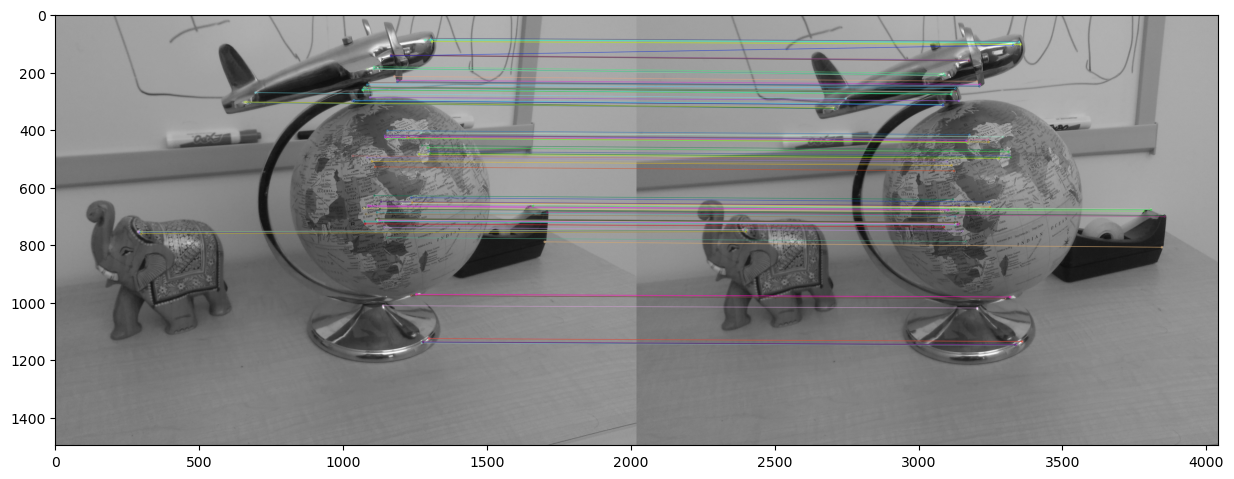

In [52]:
%matplotlib inline

# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(imgL,None)
kp2, des2 = orb.detectAndCompute(imgR,None)
# create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
# Match descriptors.
matches = bf.match(des1,des2)
# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)

N_PTS = 150

img3 = cv2.drawMatches(imgL,kp1,imgR,kp2,matches[:N_PTS],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize = (15,15)),plt.imshow(img3),plt.show();

left_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)
rght_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)

## Estimate the Essential Matrix using OpenCV


We saw that the previous DLT method for finding the essential matrix was not the most robust, so we like to use a more robust method. RANSAC is the answer, but we won't implement it ourselves. We'll use OpenCV.

Look at the OpenCV documentation for [`cv2.findEssentialMatrix`](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html#ga0b166d41926a7793ab1c351dbaa9ffd4). Which is the appropriate version (hint, we have two sets of points and a camera matrix). Note that the OpenCV function can handle pixel points, as it will convert it internally to normalised points.

<font color='blue'>
    
**Task**: estimate the essential matrix using OpenCV.

In [53]:
############################
# Your code here
E, mask = cv2.findEssentialMat(left_pts, rght_pts, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)
print(E)
print(f"Shape of E: {E.shape}")
#print(f"Number of inliers: {np.sum(mask)}")

[[ 0.00948717  0.1266446  -0.07120062]
 [-0.05517258 -0.00288334 -0.70137217]
 [ 0.08237132  0.69067274  0.00353425]]
Shape of E: (3, 3)


Now let's draw the epipolar lines





<font color='blue'>
    
**Task:** Pick a handful of the features, draw the features (in both images), and draw the corresponding epipolar lines in the right hand image. Plot the resulting image pair.
    
Notes:
* This is basically the same as the last assignment.

## Display Feature Correspondences

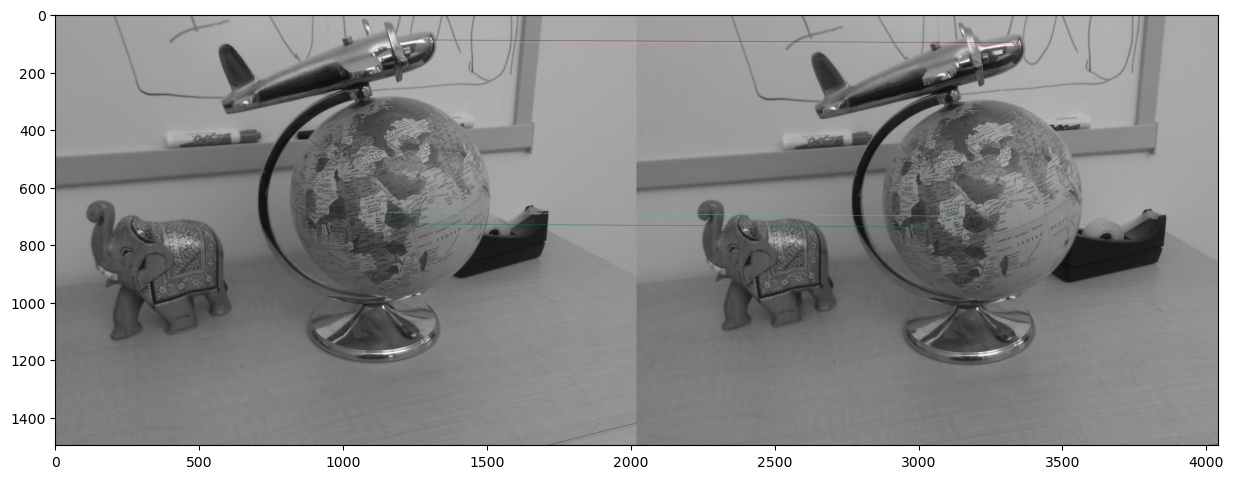

In [54]:
############################
# Your code here

# Pick 4 correspondences between left_pts and rght_pts and match the features between the frames
N_PTS = 4

# Create, then stack left and right images to give complete image for drawing matches
imgL_rgb = cv2.cvtColor(imgL, cv2.COLOR_GRAY2RGB)
imgR_rgb = cv2.cvtColor(imgR, cv2.COLOR_GRAY2RGB)
img4 = np.hstack([imgL_rgb, imgR_rgb])

# Pick 4 correspondences between left_pts and rght_pts and match the features between the frames
img4 = cv2.drawMatches(imgL,kp1,imgR,kp2,matches[:N_PTS],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize = (15,15)),plt.imshow(img4),plt.show();

left_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)
rght_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)



## Draw circles around feature correspondences

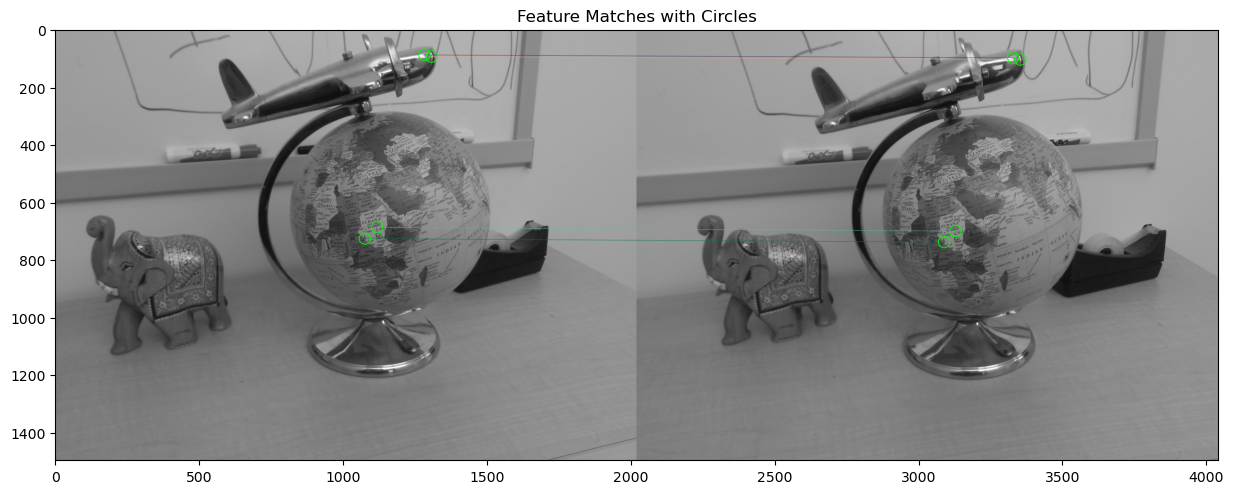

In [55]:
#Select the features in the left and right images and draw a small circle around them
img_circle = img4.copy() # Make a copy to draw on, so original img4 is preserved 

# Get the width of the left image for offsetting right image points
imgL_width = imgL.shape[1]

# Define circle parameters
radius = 20
color = (0, 255, 0) # Green color in BGR for OpenCV, but matplotlib expects RGB, so it will appear green.
thickness = 2

# Draw circles on left image points
for pt in left_pts:
    center = (int(pt[0]), int(pt[1]))
    cv2.circle(img_circle, center, radius, color, thickness)

# Draw circles on right image points (adjusting x-coordinate)
for pt in rght_pts:
    center = (int(pt[0] + imgL_width), int(pt[1]))
    cv2.circle(img_circle, center, radius, color, thickness)

# Display the image with circles
plt.figure(figsize = (15,15))
plt.imshow(img_circle)
plt.title('Feature Matches with Circles')
plt.show()

## Homogenise and Normalise features

In [62]:
# Calculate K inverse
K_inv = np.linalg.inv(K)
print(K_inv)

#Convert left points and right points to homogenous co-ordinates
left_pts_hom = np.append(left_pts, np.ones((left_pts.shape[0], 1)), axis=1)
rght_pts_hom = np.append(rght_pts, np.ones((rght_pts.shape[0], 1)), axis=1)

#Initialise lists for left_pts_dist and rght_pts_dist
left_pts_dist = np.zeros((left_pts_hom.shape[0], 3))
rght_pts_dist = np.zeros((rght_pts_hom.shape[0], 3))

#Apply normalisation
for i in range(left_pts_hom.shape[0]):
    left_pts_dist[i] = np.dot(K_inv, left_pts_hom[i])
    rght_pts_dist[i] = np.dot(K_inv, rght_pts_hom[i])

print(left_pts_hom.shape)
print(rght_pts_dist.shape)

[[ 5.24694032e-04  0.00000000e+00 -5.52844117e-01]
 [ 0.00000000e+00  5.27073593e-04 -4.10876002e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
(4, 3)
(4, 3)


## Get epipolar line and get line in pixel coordinates

In [57]:
# Initialize a list to store all epipolar lines in pixel coordinates
epipolar_lines_img = []

# Loop through each normalized left point
for i in range(left_pts_dist.shape[0]):
    # Get the epipolar line in the right normalized image,multiply by essential matrix as given in notes above
    l_ = np.dot(E, left_pts_dist[i])

    # Get the line in pixel coordinates as given in notes above
    l_img = np.dot(K_inv.T, l_)

    # Append to the list
    epipolar_lines_img.append(l_img)

print("Calculated epipolar lines (pixel coordinates):")
for line in epipolar_lines_img:
    print(line)

Calculated epipolar lines (pixel coordinates):
[-4.03966221e-05 -3.70583277e-04  3.04440042e-01]
[-3.91323393e-05 -3.69979940e-04  3.15109854e-01]
[-6.06548615e-05 -3.73014368e-04  1.20178534e-01]
[-6.09221202e-05 -3.72636376e-04  1.16994339e-01]


## Function to calculate the points of the epipolar line

In [58]:
#Define function to calculate the points of the epipolar line
def calc_epipolar_line(pixel_coordinates, img_width):
  # Ensure pixel_coordinates is a NumPy array for consistent behavior
  pixel_coordinates = np.asarray(pixel_coordinates)

  # Correct length check
  if pixel_coordinates.shape != (3,):
    print("Error: pixel_coordinates must be a 3-element vector (s_img, t_img, v_img)")
    return None, None # Return None for both points to indicate failure

  s_img = pixel_coordinates[0]
  t_img = pixel_coordinates[1]
  v_img = pixel_coordinates[2]

  # Calculate y-coordinates for x=0 and x=img_width
  x0 = 0
  y0 = (-v_img - s_img * x0) / t_img

  x1 = img_width
  y1 = (-v_img - s_img * x1) / t_img

  # Return integer pixel coordinates
  pt0 = (int(x0), int(y0))
  pt1 = (int(x1), int(y1))

  return pt0, pt1

## Calculate Epipolar Line points

In [59]:
epi_points=[]
for line in epipolar_lines_img:
    points = calc_epipolar_line(line, imgR.shape[1])
    epi_points.append(points)
print(epi_points)

[((0, 821), (2020, 601)), ((0, 851), (2020, 638)), ((0, 322), (2020, -6)), ((0, 313), (2020, -16))]


## Draw epipolar line on image

(2020, 821) (4040, 601)
(2020, 851) (4040, 638)
(2020, 322) (4040, -6)
(2020, 313) (4040, -16)


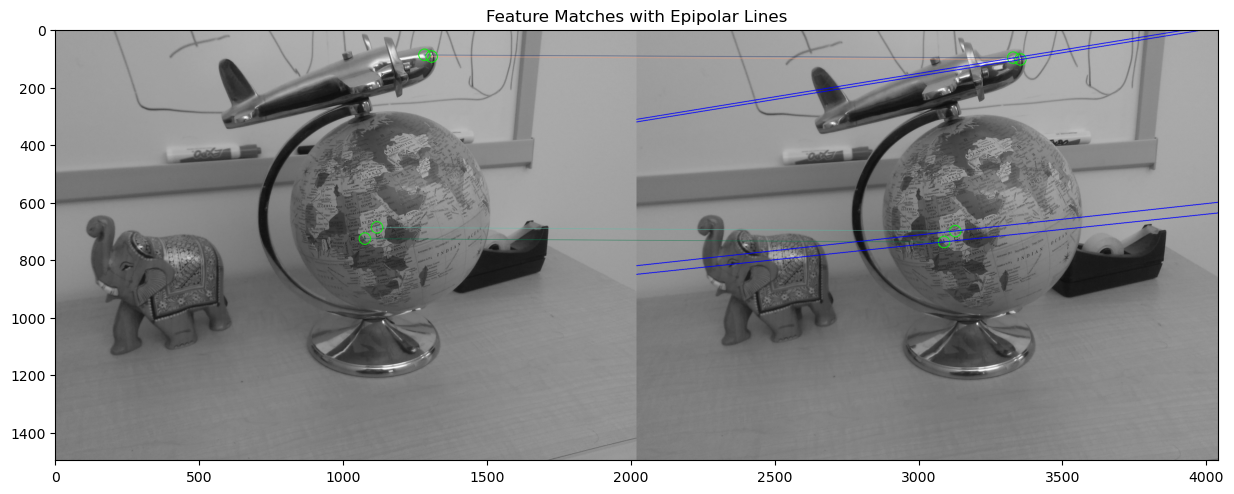

In [60]:
img = img_circle.copy() # Use the image with circles drawn on it
# Draw a blue line (BGR: 0, 0, 255)
imgL_width = imgL.shape[1]
for points in epi_points:
    pt0 = (points[0][0] + imgL_width, points[0][1])
    pt1 = (points[1][0] + imgL_width, points[1][1])
    cv2.line(img, pt0, pt1, (0, 0, 255), 2)
    print(pt0, pt1)
# Display the image with epipolar line using matplotlib
plt.figure(figsize = (15,15))
plt.imshow(img)
plt.title('Feature Matches with Epipolar Lines')
plt.show()

## Decompose the essential matrix

Remember that the essential matrix is made up from a rotation matrix $\mathbf{R}$ and a translation vector $\mathbf{t}$, i.e., $\mathbf{E} = \left[\mathbf{t}\right]_\times \mathbf{R}$. Often we will want to deconstruct the essential matrix into its constituent parts $\mathbf{E} \rightarrow \mathbf{R}, \mathbf{t}$.

However, there is a theoretical ambiguity when reconstructing the relative poses of two cameras from the essential matrix. This ambiguity is linked to the fact that, given a 2D point in an image, the pinhole camera model cannot tell whether the corresponding 3D point is in front of the camera or behind the camera. Fundamentally, for a given essential matrix, we cannot distinguish the following scenarios.

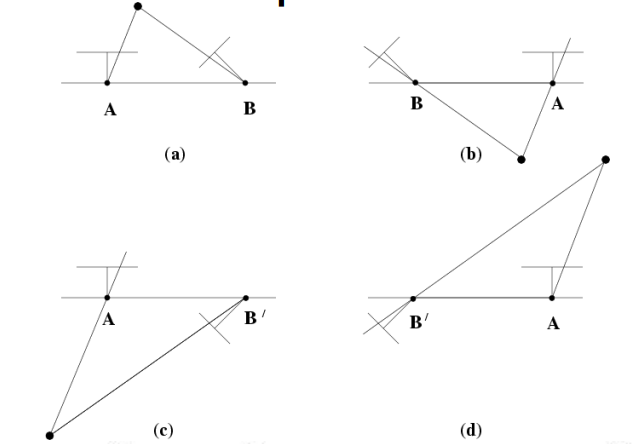

In order to remove this ambiguity, you need to know at least one point correspondence in the images: as these two 2D points are assumed to be the projections of a single 3D point lying in front of both cameras (since it is visible in both images), this will enable choosing the right $\mathbf{R}$ and $\mathbf{t}$. The details for this are [provided here](https://stackoverflow.com/questions/22807039/decomposition-of-essential-matrix-validation-of-the-four-possible-solutions-for).

Luckily, OpenCV provides a function for this - [`cv2.recoverPose`](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html#gadb7d2dfcc184c1d2f496d8639f4371c0)

<font color='blue'>
    
**Task**: Decompose the essential matrix, and select the correct rotation and translation, using OpenCV

In [75]:
############################
# Your code here
E_dc = cv2.recoverPose(E, left_pts_dist[:, :2], rght_pts_dist[:, :2])
print("Recovered Pose (R, t):")
print(E_dc)
print('\n')
R = E_dc[1]
print("Rotation Matrix R:")
print(R)
print('\n')
t = E_dc[2]
print("Translation Vector t:")
print(t)



Recovered Pose (R, t):
(4, array([[ 0.99452797, -0.01650523,  0.10315856],
       [ 0.01715971,  0.99983785, -0.00546017],
       [-0.10305171,  0.00720047,  0.99464994]]), array([[-0.97857203],
       [ 0.10024718],
       [ 0.1798535 ]]), array([[255],
       [255],
       [255],
       [255]], dtype=uint8))


Rotation Matrix R:
[[ 0.99452797 -0.01650523  0.10315856]
 [ 0.01715971  0.99983785 -0.00546017]
 [-0.10305171  0.00720047  0.99464994]]


Translation Vector t:
[[-0.97857203]
 [ 0.10024718]
 [ 0.1798535 ]]


## Triangulate points

Now we are going to reconstruct the scene through triangulation. That is, for each of the features, we will estimate what the 3D point is. We are going to use [`cv2.triangulatePoints`](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html#gad3fc9a0c82b08df034234979960b778c) to do this. Look carefully at the documentation.



<font color='blue'>

**Task**: Triangulate the points to create the 3D points, and display them in a 3D plot. Use the `cv2.triangulatePoints` function.
    
**Notes**: 
* OpenCV is very inconsistent in the format of the arrays it expects. We have to be careful. The function `cv2.triangulatePoints` expects row order points to be passed, so we must pass the transpose of the np.arrays that contain the point correspondences (`left_pts.T` and `rght_pts.T`). But note that `cv2.recoverPose` above does not require this. Just something to be careful about. Note also to check if you need to transpose the array it returns.
* `triangulatePoints` expects the projection matrices as input. You need to build them out of the camera intrinsics matrix and the rotation/translation that you extracted from the essential matrix. Recall Lecture 4.6:
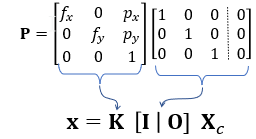
and
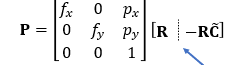
The first equation is for the camera with no rotation/translation, and the second is the case of the non-zero rotation and translation.
Note that the translation vector returned from `cv2.recoverPose` is already the negative, so you can ignore the `-` in the second equation.
* `cv2.triangulatePoints` returns the 3D points in homogeneous form (i.e., as 4-vectors). You need to dehomogenise them.
* When plotting in 3D using matplotlib (A quick google will tell you how to do this), you can enable an interactive plot that you can drag around. Do this by putting the command `%matplotlib notebook` at the top of the cell. If you run this cell, though, and then rerun one of the cells above, the plots above can look weird. To fix this, you can add the line `%matplotlib inline` to the other cells.

In [74]:
############################
# Your code here
#%matplotlib notebook
%matplotlib inline  
#Define the projection matrices for the two cameras - first define the homogenous perspective projection matrix for the first camera, 
# then use the recovered pose to define the second camera's projection matrix.  
# Homogenous perspective projection matrix for the first camera
I = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0],
              [0, 0, 1, 0]])

P1 = np.dot(K, I) # Projection matrix for the first camera
print(P1)
print('\n')
P2 = np.dot(K, np.hstack((R, t))) # Projection matrix for the second camera
print(P2)
print('\n')
# Get output triangulation vectors in homogenous form
points_3d = cv2.triangulatePoints(P1, P2, left_pts_dist[:, :2].T, rght_pts_dist[:, :2].T)
print("Triangulated 3D points:")
print(points_3d.T)
print('\n')
#Need to de-homogenise the triangulated 3D points by dividing by the 4th coordinate
points_3d_dehom = points_3d / points_3d[3]
print("De-homogenised 3D points:")
print(points_3d_dehom.T)

[[1.90750838e+03 0.00000000e+00 1.05455479e+03 0.00000000e+00]
 [0.00000000e+00 1.89845416e+03 7.80029253e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]


[[ 1.78839676e+03 -2.38905724e+01  1.24568867e+03 -1.67696899e+03]
 [-4.78064253e+01  1.90376290e+03  7.65490161e+02  3.30605657e+02]
 [-1.03051715e-01  7.20046551e-03  9.94649937e-01  1.79853496e-01]]


Triangulated 3D points:
[[ 0.45141324  0.34690084 -0.81266133 -0.12436825]
 [ 0.45142199  0.34689155 -0.81266035 -0.12436877]
 [ 0.45135939  0.34702864 -0.81263971 -0.12434843]
 [ 0.45136349  0.3470291  -0.81263717 -0.12434881]]


De-homogenised 3D points:
[[-3.62965025 -2.78930392  6.53431519  1.        ]
 [-3.62970528 -2.78921746  6.53427981  1.        ]
 [-3.62979576 -2.79077629  6.53518295  1.        ]
 [-3.62981741 -2.79077128  6.53514207  1.        ]]


## Display triangulated points

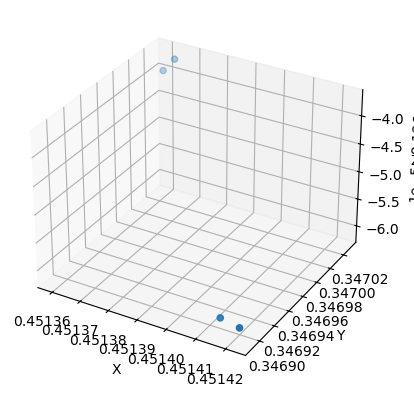

In [76]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_3d[0], points_3d[1], points_3d[2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

<font color='blue'>

# Questions

<font color='blue'>

**Question**: Comment on the epipolar lines. How do they look in comparison to the pure DLT method previously used?

<font color='blue'>

**Question**: When we recovered the relative pose of the cameras from the essential matrix, what was the length of the translation vector? Can you explain this length?

<font color='blue'>

**Question**: Describe the reconstruction of the points? Do they make sense to you? It may be worth drawing the images with the feature correspondence side-by-side the 3D plot so you can compare.

<font color='blue'>

**Question**: What unit are the 3D points in (trick question)? Explain your answer, and refer to the 3D plot.